In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
'''master_log = pd.read_csv('trading_logs/master_daily_log.csv')
trade_log = pd.read_csv('trading_logs/trade_log.csv')'''
master_log = pd.read_csv('trading_logs/master_daily_log_fast.csv')
trade_log = pd.read_csv('trading_logs/trade_log_fast.csv')

# 2. Convert dates to datetime objects for easy plotting
master_log['date'] = pd.to_datetime(master_log['date'])
if 'entry_time' in trade_log.columns:
    trade_log['entry_time'] = pd.to_datetime(trade_log['entry_time'])
if 'exit_time' in trade_log.columns:
    trade_log['exit_time'] = pd.to_datetime(trade_log['exit_time'])

# 3. View the first few rows of your 20 trades
trade_log
master_log.head(30)




,date,current_price,market_regime,theta,mu,sigma,z_score,median_z,std_zscore,lower_ci,upper_ci,skew_z,kurt_z,ev,action_bought,action_sold,cash_balance,raw_data_path
0,2024-08-27 09:30:00,71.320000,2,0.016362,76.671553,0.561475,-1.742103,-1.742103,3.944069,-8.628919,4.411796,-0.138686,-0.467818,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
1,2024-08-27 10:30:00,71.339996,2,0.016362,76.671553,0.561475,-1.735480,-1.735480,3.947633,-8.624741,4.428068,-0.137087,-0.468357,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
2,2024-08-27 11:30:00,71.199997,2,0.016362,76.671553,0.561475,-1.781149,-1.781149,3.922717,-8.650974,4.314838,-0.148326,-0.464468,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
3,2024-08-27 12:30:00,71.375000,2,0.016362,76.671553,0.561475,-1.723912,-1.723912,3.953876,-8.617793,4.456723,-0.134293,-0.469289,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
4,2024-08-27 13:30:00,71.410004,2,0.016362,76.671553,0.561475,-1.712413,-1.712413,3.960125,-8.610923,4.485394,-0.131507,-0.470204,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
5,2024-08-27 14:30:00,71.404999,2,0.016362,76.671553,0.561475,-1.714049,-1.714049,3.959231,-8.611906,4.481123,-0.131905,-0.470074,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
6,2024-08-27 15:30:00,71.370003,2,0.016362,76.671553,0.561475,-1.725615,-1.725615,3.952985,-8.618553,4.452686,-0.134692,-0.469157,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240827.npy
7,2024-08-28 09:30:00,71.610001,2,0.046843,68.850068,0.606117,1.381586,1.381586,2.357805,-2.368604,5.010987,-0.022408,-0.949068,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240828.npy
8,2024-08-28 10:30:00,71.480003,2,0.046843,68.850068,0.606117,1.316487,1.316487,2.336290,-2.411852,4.910189,-0.027595,-0.940392,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240828.npy
9,2024-08-28 11:30:00,71.599998,2,0.046843,68.850068,0.606117,1.376445,1.376445,2.356147,-2.371695,5.003119,-0.022802,-0.948413,0.0,False,False,100000.0,mcmc_samples_backups/mcmc_20240828.npy


In [ ]:


# Ensure date is sorted to get the true "final" day
master_log['date'] = pd.to_datetime(master_log['date'], utc=True).dt.tz_localize(None)
master_log = master_log.sort_values('date')

# Calculate performance
initial_cash = 100000.0  # Set this to match your PairsPortfolioManager(initial_cash=...)
final_cash = master_log['cash_balance'].iloc[-1]

total_pnl = final_cash - initial_cash
roi = (total_pnl / initial_cash) * 100

print(f"--- Final Performance Summary ---")
print(f"Starting Cash: ${initial_cash:,.2f}")
print(f"Final Cash:    ${final_cash:,.2f}")
print(f"Total PnL:     ${total_pnl:,.2f}")
print(f"Return on Inv: {roi:.2f}%")

--- Final Performance Summary ---
Starting Cash: $100,000.00
Final Cash:    $110,509.13
Total PnL:     $10,509.13
Return on Inv: 10.51%


In [ ]:
import pandas as pd

# Assuming your DataFrame is named trade_log

# 1. Calculate the percentage return for each individual trade
# Formula: PnL / (Position Size * Entry Price)
trade_log['pct_return'] = trade_log['profit_loss'] / (trade_log['size'] * trade_log['entry_price'])

# 2. Filter the DataFrame into winners (PnL > 0) and losers (PnL < 0)
winners = trade_log[trade_log['profit_loss'] > 0]
losers = trade_log[trade_log['profit_loss'] < 0]

# 3. Calculate the average percentage return and convert to a readable format (x 100)
avg_win_pct = winners['pct_return'].mean() * 100
avg_loss_pct = losers['pct_return'].mean() * 100

# 4. Print the results
print(f"Average Winning Trade Return: {avg_win_pct:.2f}%")
print(f"Average Losing Trade Return: {avg_loss_pct:.2f}%")

Start Date: 2024-09-25 10:30:00
End Date (1 Year Later): 2025-09-25 10:30:00
Total PnL for the first year: $10509.13


In [ ]:
import pandas as pd
import numpy as np

# Assuming master_log and trade_log are already loaded DataFrames
# 1. Ensure datetime formats
trade_log['entry_time'] = pd.to_datetime(trade_log['entry_time'])
trade_log['exit_time'] = pd.to_datetime(trade_log['exit_time'])
master_log['date'] = pd.to_datetime(master_log['date'])

# 1. Total Number of Trades

total_trades = len(trade_log)


# 2. Profit Factor

gross_profit = trade_log[trade_log['profit_loss'] > 0]['profit_loss'].sum()
gross_loss = abs(trade_log[trade_log['profit_loss'] < 0]['profit_loss'].sum())

# Handle edge case if there are zero losing trades
if gross_loss == 0:
    profit_factor = float('inf')
else:
    profit_factor = gross_profit / gross_loss


# 3. Expectancy (Expected Return per Trade)

# Re-calculate individual trade % returns based on initial position value
trade_log['pct_return'] = trade_log['profit_loss'] / (trade_log['size'] * trade_log['entry_price'])

winners = trade_log[trade_log['pct_return'] > 0]
losers = trade_log[trade_log['pct_return'] < 0]

win_rate = len(winners) / total_trades
loss_rate = len(losers) / total_trades

avg_win_pct = winners['pct_return'].mean()
avg_loss_pct = abs(losers['pct_return'].mean()) # Absolute value for the formula

expectancy = (win_rate * avg_win_pct) - (loss_rate * avg_loss_pct)
expectancy_pct = expectancy * 100


# 4. Average Time in Market

trade_log['duration'] = trade_log['exit_time'] - trade_log['entry_time']
avg_duration = trade_log['duration'].mean()


# 5. Maximum Drawdown (Using master_log)

# Sort chronologically just to be safe
master_log = master_log.sort_values('date')

# Track the highest cash balance recorded up to each point in time
rolling_max = master_log['cash_balance'].cummax()

# Calculate the percentage drop from the highest peak
drawdowns = (master_log['cash_balance'] - rolling_max) / rolling_max
cash = 100000
max_drawdown_pct = losers['pct_return'].min() * 100


# 6. Sharpe Ratio (Annualized)

# Get the final cash balance of each individual day
daily_balances = master_log.groupby(master_log['date'].dt.date)['cash_balance'].last()

# Calculate daily percentage returns
daily_returns = daily_balances.pct_change().dropna()

# Annualize it (assuming 252 trading days in a year, and a risk-free rate of 0 for simplicity)
if daily_returns.std() != 0:
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
else:
    sharpe_ratio = 0.0



# Print Results in Markdown Format

print("## Advanced Performance Metrics\n")
print(f"* **Total Trades Taken:** {total_trades}")
print(f"* **Profit Factor:** {profit_factor:.2f}")
print(f"* **Expectancy Per Trade:** {expectancy_pct:.2f}%")
print(f"* **Average Time in Market:** {avg_duration}")
print(f"* **Maximum Drawdown:** {max_drawdown_pct:.2f}%")
print(f"* **Sharpe Ratio:** {sharpe_ratio:.2f}")

## Advanced Performance Metrics

* **Total Trades Taken:** 18
* **Profit Factor:** 4.50
* **Expectancy Per Trade:** 0.97%
* **Average Time in Market:** 10 days 18:20:00
* **Maximum Drawdown:** -1.30%
* **Sharpe Ratio:** 1.17


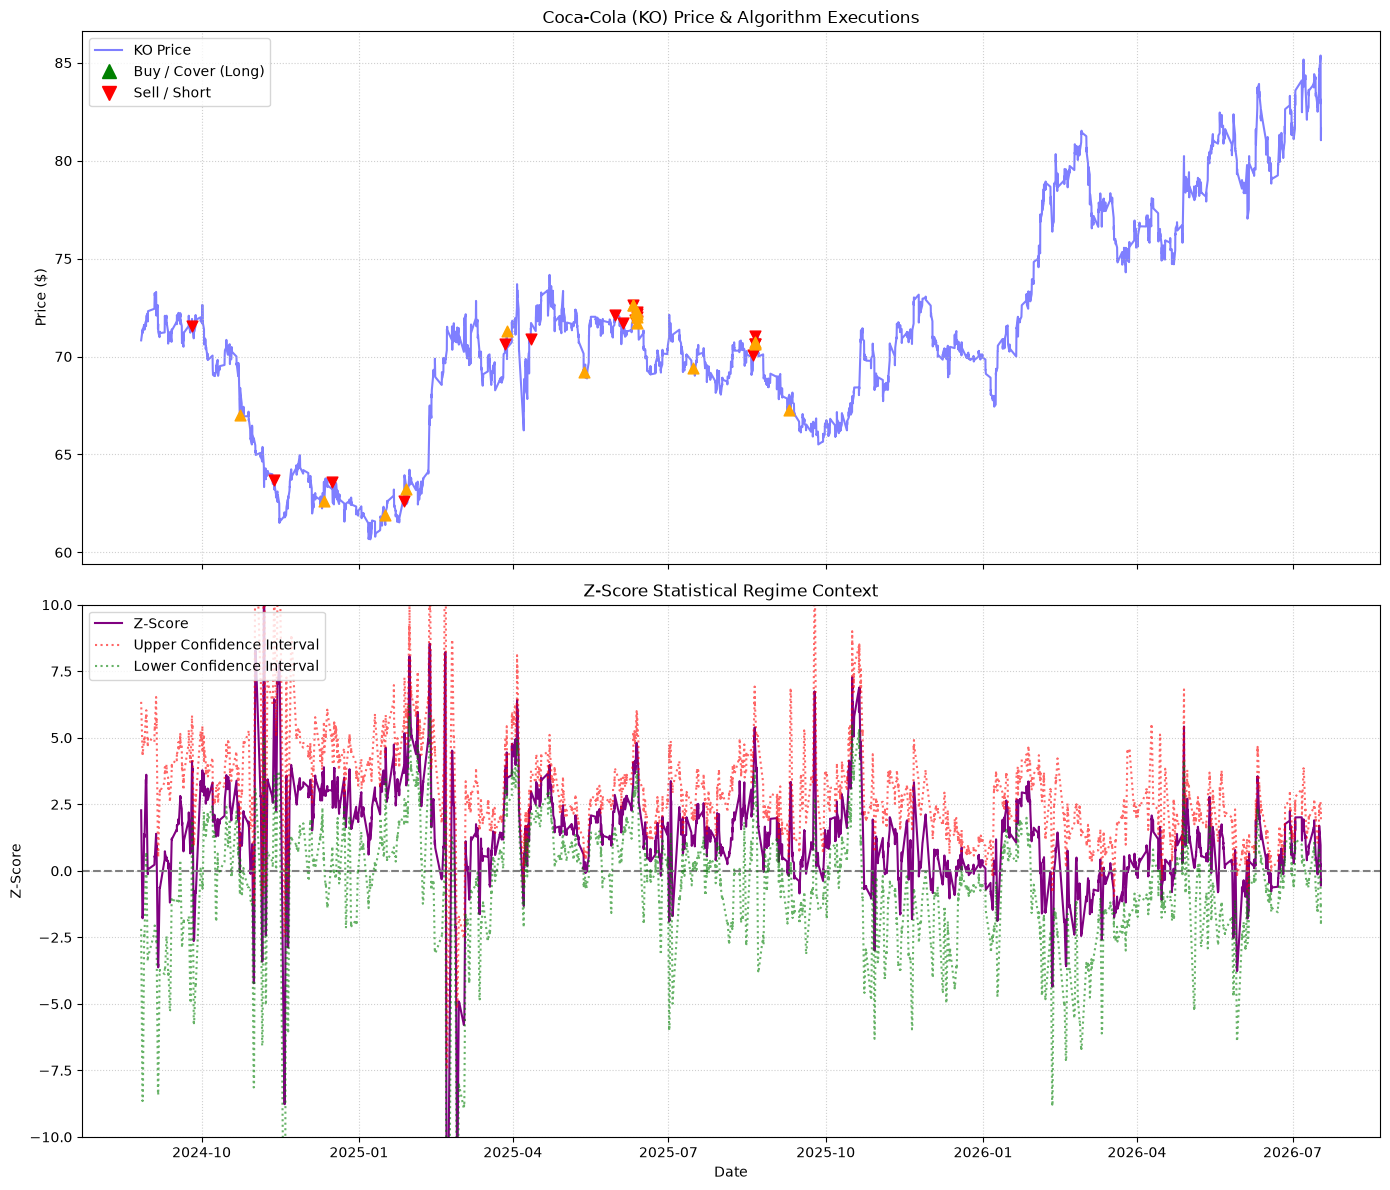

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.lines as mlines

# Assuming your data is loaded as 'master_log' and 'trade_log'
df = master_log.copy()
df_signals = trade_log.copy()

# 1. Clean column names to prevent whitespace errors
df.columns = df.columns.str.strip()
df_signals.columns = df_signals.columns.str.strip()

# 2. Convert to timezone-naive datetime objects so they align perfectly on the X-axis
df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)

df_signals['entry_time'] = pd.to_datetime(df_signals['entry_time'], utc=True).dt.tz_localize(None)
df_signals['exit_time'] = pd.to_datetime(df_signals['exit_time'], utc=True).dt.tz_localize(None)

# 3. Separate the signals using your exact column 'trade_type'
long_trades = df_signals[df_signals['trade_type'] == 'LONG']
short_trades = df_signals[df_signals['trade_type'] == 'SHORT']

# 4. Setup the 2-pane figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Custom legend markers to reuse
buy_marker = mlines.Line2D([], [], color='green', marker='^', linestyle='None', markersize=10, label='Buy / Cover (Long)')
sell_marker = mlines.Line2D([], [], color='red', marker='v', linestyle='None', markersize=10, label='Sell / Short')


# PANE 1: KO Price & Executions

ax1.plot(df['date'], df['current_price'], label='KO Price', color='blue', alpha=0.5, zorder=1)

# Long Executions
ax1.scatter(long_trades['entry_time'], long_trades['entry_price'], color='green', marker='^', s=60, zorder=3)
ax1.scatter(long_trades['exit_time'], long_trades['exit_price'], color='blue', marker='v', s=60, zorder=3)

# Short Executions
ax1.scatter(short_trades['entry_time'], short_trades['entry_price'], color='red', marker='v', s=60, zorder=3)
ax1.scatter(short_trades['exit_time'], short_trades['exit_price'], color='orange', marker='^', s=60, zorder=3)

handles, labels = ax1.get_legend_handles_labels()
handles.extend([buy_marker, sell_marker])
ax1.set_title("Coca-Cola (KO) Price & Algorithm Executions")
ax1.legend(handles=handles, loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_ylabel('Price ($)')


# PANE 2: Plot Z-Score with Confidence Intervals

ax2.plot(df['date'], df['z_score'], label='Z-Score', color='purple')
ax2.axhline(0, color='gray', linestyle='--')
ax2.plot(df['date'], df['upper_ci'], color='red', linestyle=':', alpha=0.6, label='Upper Confidence Interval')
ax2.plot(df['date'], df['lower_ci'], color='green', linestyle=':', alpha=0.6, label='Lower Confidence Interval')

# Set y-limits on Z-Score to cut off extreme outliers and focus on the regime
ax2.set_ylim(-10, 10) 

ax2.set_title("Z-Score Statistical Regime Context")
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go


# 1. Load the Data

print("Loading logs for interactive plotting...")
log_folder = "trading_logs"

df_master = pd.read_csv(f"{log_folder}/master_daily_log_fast.csv")
df_master['date'] = pd.to_datetime(df_master['date'])

df_trades = pd.read_csv(f"{log_folder}/trade_log_fast.csv")
df_trades['entry_time'] = pd.to_datetime(df_trades['entry_time'])
df_trades['exit_time'] = pd.to_datetime(df_trades['exit_time'])


# 2. Initialize the Interactive Figure

fig = go.Figure()


# 3. Plot the Regimes (The Price Line)

regime_colors = {0: 'lightgreen', 1: 'purple', 2: 'orange'} # Light Green, Purple, Orange

for regime_id in sorted(df_master['market_regime'].dropna().unique()):
    subset = df_master[df_master['market_regime'] == regime_id]
    
    fig.add_trace(go.Scatter(
        x=subset['date'], 
        y=subset['current_price'],
        mode='markers',
        marker=dict(color=regime_colors.get(regime_id, 'white'), size=4, opacity=0.6),
        name=f'Regime {int(regime_id)}',
        hoverinfo='x+y+name' # Shows data when you hover!
    ))


# 4. Plot the Trades

longs = df_trades[df_trades['trade_type'] == 'LONG']
shorts = df_trades[df_trades['trade_type'] == 'SHORT']

# -- LONG TRADES --
if not longs.empty:
    # Buy (Entry)
    fig.add_trace(go.Scatter(
        x=longs['entry_time'], y=longs['entry_price'],
        mode='markers',
        marker=dict(symbol='triangle-up', size=14, color='lime', line=dict(width=1, color='black')),
        name='Buy (Long Entry)'
    ))
    # Sell (Exit)
    fig.add_trace(go.Scatter(
        x=longs['exit_time'], y=longs['exit_price'],
        mode='markers',
        marker=dict(symbol='circle', size=10, color='darkgreen', line=dict(width=1, color='white')),
        name='Sell (Long Exit)'
    ))

# -- SHORT TRADES --
if not shorts.empty:
    # Short (Entry)
    fig.add_trace(go.Scatter(
        x=shorts['entry_time'], y=shorts['entry_price'],
        mode='markers',
        marker=dict(symbol='triangle-down', size=14, color='red', line=dict(width=1, color='black')),
        name='Short (Entry)'
    ))
    # Cover (Exit)
    fig.add_trace(go.Scatter(
        x=shorts['exit_time'], y=shorts['exit_price'],
        mode='markers',
        marker=dict(symbol='circle', size=10, color='cyan', line=dict(width=1, color='black')),
        name='Cover (Short Exit)'
    ))


# 5. Add the Interactive Range Slider (Dynamic Window)

fig.update_layout(
    title="Interactive KO Simulation: Drag to Zoom / Use Slider to Change Window",
    xaxis_title="Date",
    yaxis_title="KO Price ($)",
    template="plotly_dark", # Gives it a clean, professional dark-mode trading look
    hovermode="closest",
    
    # THIS is what lets you dynamically size the viewing window!
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="date"
    )
)

# Render the interactive chart
fig.show()

Loading logs for interactive plotting...


In [11]:

# 3. Filter trades by Profit/Loss
winning_trades = df_trades[df_trades['profit_loss'] > 0]
losing_trades = df_trades[df_trades['profit_loss'] < 0]

# 4. Merge the Master Log with the filtered trades based on ENTRY time
df_master_winners = pd.merge(df_master, winning_trades, left_on='date', right_on='entry_time', how='inner')
df_master_losers = pd.merge(df_master, losing_trades, left_on='date', right_on='entry_time', how='inner')

print(f"Total Winning Entries Found: {len(df_master_winners)}")
print(f"Total Losing Entries Found: {len(df_master_losers)}")

# Display the math behind your losing trades to see what went wrong
display(df_master_losers[['date', 'market_regime', 'z_score','current_price','mu','theta','raw_data_path','exit_reason','ev', 'profit_loss', 'trade_type']].tail(50))
# Count the regimes for winners and losers
winners_by_regime = df_master_winners['market_regime'].value_counts().rename("Winners")
losers_by_regime = df_master_losers['market_regime'].value_counts().rename("Losers")

# Combine them side-by-side, fill missing values with 0, and make them whole numbers
regime_breakdown = pd.concat([winners_by_regime, losers_by_regime], axis=1).fillna(0).astype(int)

# Add Total Trades and Win Rate for context
regime_breakdown['Total Trades'] = regime_breakdown['Winners'] + regime_breakdown['Losers']
regime_breakdown['Win Rate (%)'] = (regime_breakdown['Winners'] / regime_breakdown['Total Trades'] * 100).round(2)

# Give the index a clean name
regime_breakdown.index.name = 'Market Regime'

# Display beautifully in Jupyter
display(regime_breakdown)

Total Winning Entries Found: 10
Total Losing Entries Found: 7


,date,market_regime,z_score,current_price,mu,theta,raw_data_path,exit_reason,ev,profit_loss,trade_type
0,2025-01-27 10:30:00,0,3.677738,62.630001,59.462002,0.149521,mcmc_samples_backups/mcmc_20250127.npy,stop_loss,3.1123,-696.598228,SHORT
1,2025-03-27 10:30:00,0,3.718749,70.654999,67.290010,1.114315,mcmc_samples_backups/mcmc_20250327.npy,stop_loss,3.3859,-266.700897,SHORT
2,2025-05-30 14:30:00,0,2.653163,72.105003,69.111056,0.332716,mcmc_samples_backups/mcmc_20250530.npy,stop_loss,3.0166,-319.277939,SHORT
3,2025-06-04 13:30:00,0,2.577357,71.690002,69.027082,0.325440,mcmc_samples_backups/mcmc_20250604.npy,stop_loss,2.5673,-590.918457,SHORT
4,2025-06-11 10:30:00,0,3.656998,71.885002,68.972025,0.873226,mcmc_samples_backups/mcmc_20250611.npy,stop_loss,2.9197,-194.178864,SHORT
5,2025-06-12 13:30:00,0,4.156981,71.790001,68.872540,0.561360,mcmc_samples_backups/mcmc_20250612.npy,stop_loss,2.9093,-170.998840,SHORT
6,2025-08-20 13:30:00,0,4.791822,70.650002,67.538100,0.347450,mcmc_samples_backups/mcmc_20250820.npy,stop_loss,3.0625,-31.738708,SHORT


,Winners,Losers,Total Trades,Win Rate (%)
Market Regime,,,,
0,10,7,17,58.82


In [10]:
profit_dfm = pd.concat([df_master_losers, df_master_winners], ignore_index=True)

non_regime1_pl = profit_dfm.loc[profit_dfm['market_regime'] == 0, 'profit_loss'].sum()
non_regime1_pl
# Only keep the three exit reasons you care about
exit_reasons = ["stop_loss", "take_profit", "time_stop"]

exit_reason_summary = (
    profit_dfm[profit_dfm['exit_reason'].isin(exit_reasons)]
    .groupby('exit_reason')
    .agg({
        'profit_loss': 'mean',
        'z_score': 'mean',
        'ev': 'mean',
        'theta': 'mean',
        'current_price': 'mean',
        'mu': 'mean'
    })
    .round(4)
)

display(exit_reason_summary)
non_regime1_pl


,profit_loss,z_score,ev,theta,current_price,mu
exit_reason,,,,,,
stop_loss,59.8495,3.9477,3.1672,0.4836,70.2446,67.0520
take_profit,2630.5129,3.6650,3.4537,0.4919,71.0400,67.5636
time_stop,1335.5021,5.5891,8.2796,0.2852,67.9350,52.7961


np.float64(11280.736343383789)

In [30]:
import pandas as pd

# 1. Isolate all the negative trades
negative_trades = df_signals[df_signals['profit_loss'] < 0].copy()

# 2. Ensure both DataFrames have perfectly matching, timezone-naive datetimes
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)

negative_trades['exit_time'] = pd.to_datetime(negative_trades['exit_time'], utc=True).dt.tz_localize(None)

# 3. Extract a list of ALL the exit times from those losing trades
all_exit_times = negative_trades['exit_time'].tolist()

# 4. Filter the raw data 'df' to grab the rows where the date matches ANY of those exit times
all_negative_exits_df = df[df['date'].isin(all_exit_times)].copy()

# 5. Sort chronologically so it's easy to read
all_negative_exits_df = all_negative_exits_df.sort_values('date')

# 6. Show all the columns (optional, but helpful for debugging)
pd.set_option('display.max_columns', None)

# View the final DataFrame of all your losing exit rows

import pandas as pd

# 1. Isolate all the negative trades
positive_positive = df_signals[df_signals['profit_loss'] > 0].copy()

# 2. Ensure both DataFrames have perfectly matching, timezone-naive datetimes
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)

positive_positive['exit_time'] = pd.to_datetime(positive_positive['exit_time'], utc=True).dt.tz_localize(None)

# 3. Extract a list of ALL the exit times from those losing trades
all_exit_times = positive_positive['exit_time'].tolist()

# 4. Filter the raw data 'df' to grab the rows where the date matches ANY of those exit times
all_positive_exits_df = df[df['date'].isin(all_exit_times)].copy()

# 5. Sort chronologically so it's easy to read
all_positive_exits_df = all_positive_exits_df.sort_values('date')

# 6. Show all the columns (optional, but helpful for debugging)
pd.set_option('display.max_columns', None)

# View the final DataFrame of all your losing exit rows
all_positive_exits_df
all_negative_exits_df


,date,current_price,market_regime,theta,mu,sigma,z_score,median_z,std_zscore,lower_ci,upper_ci,skew_z,kurt_z,ev,action_bought,action_sold,cash_balance,raw_data_path
502,2024-12-06 11:30:00,62.700001,1,0.041590,58.109209,0.461346,9.950857,3.324501,1.526526,0.150675,5.569891,-0.397060,0.237489,3.6708,True,True,30724.800720,mcmc_samples_backups/mcmc_20241206.npy
590,2024-12-26 12:30:00,62.705002,1,0.410413,60.246212,0.540443,4.549586,3.819812,0.944541,2.035294,5.159364,-0.378275,0.152005,2.4643,True,True,40244.018448,mcmc_samples_backups/mcmc_20241226.npy
681,2025-01-16 12:30:00,61.884998,1,0.437468,59.728663,0.478190,4.509370,4.243117,0.691380,3.128632,5.403645,0.094431,-0.055636,2.1603,True,True,33263.806488,mcmc_samples_backups/mcmc_20250116.npy
682,2025-01-16 13:30:00,61.922798,1,0.437468,59.728663,0.478190,4.588418,4.317396,0.699480,3.190633,5.492333,0.096940,-0.059354,2.2126,True,True,33174.447678,mcmc_samples_backups/mcmc_20250116.npy
683,2025-01-16 14:30:00,61.970001,1,0.437468,59.728663,0.478190,4.687130,4.409724,0.709659,3.267798,5.603056,0.100005,-0.063900,2.2596,True,True,33062.859634,mcmc_samples_backups/mcmc_20250116.npy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540,2026-02-10 14:30:00,77.000000,2,0.006655,120.197920,0.879466,-49.118328,-4.270196,2.512108,-8.694424,-0.647945,-0.237880,-0.702098,0.0000,False,True,89398.002277,mcmc_samples_backups/mcmc_20260210.npy
2907,2026-04-28 10:30:00,79.764999,2,0.465088,75.480762,0.846906,5.058694,4.889852,0.763139,3.699992,6.174002,0.258123,0.345548,4.2150,True,True,35951.320850,mcmc_samples_backups/mcmc_20260428.npy
2908,2026-04-28 11:30:00,80.180000,2,0.465088,75.480762,0.846906,5.548714,5.361495,0.817954,4.089200,6.742191,0.279438,0.384622,4.7504,True,True,35396.879627,mcmc_samples_backups/mcmc_20260428.npy
2909,2026-04-28 12:30:00,80.235001,2,0.465088,75.480762,0.846906,5.613657,5.424039,0.825305,4.140640,6.817663,0.282004,0.389345,4.7941,True,True,35323.399220,mcmc_samples_backups/mcmc_20260428.npy


In [31]:
# Split positive and negative trades
positive_trades = df_signals[df_signals['profit_loss'] > 0].copy()
negative_trades = df_signals[df_signals['profit_loss'] < 0].copy()

# Select the first negative trade
trade_id = positive_trades['trade_id'].iloc[2]
trade_info = df_signals[df_signals['trade_id'] == trade_id].copy()

# Ensure df['date'] is datetime
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)

# Convert entry/exit timestamps
entry_time = pd.to_datetime(trade_info['entry_time'].values[0], utc=True).tz_localize(None)
exit_time  = pd.to_datetime(trade_info['exit_time'].values[0],  utc=True).tz_localize(None)

# Filter rows
entry_row = df[df['date'] == entry_time]
exit_row  = df[df['date'] == exit_time]

# Combine vertically (axis=0)
combined = pd.concat([entry_row, exit_row], axis=0)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 200)

combined
trade_info



,trade_id,entry_time,exit_time,ticker,trade_type,size,entry_price,exit_price,exit_reason,profit_loss,tick_life,time_reversion,account_cash_balance
2,TRADE_B14707,2024-10-22 12:30:00,2024-10-23 09:30:00,KO,SHORT,861,69.625,66.989998,take_profit,2268.736839,4,NaN,104077.672661


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
trade_info = df_signals[df_signals['trade_id'] == "PAIR_2E286A"]
trade_info
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)

# 1. Extract entry and exit times cleanly
entry_time = pd.to_datetime(trade_info['entry_time'].values[0]).tz_localize(None)
exit_time = pd.to_datetime(trade_info['exit_time'].values[0]).tz_localize(None)

# Add a 3-day buffer to visualize the context around the trade
time_buffer = pd.Timedelta(days=3) 
window_start = entry_time - time_buffer
window_end = exit_time + time_buffer

# 2. Filter the dataframe for the plotting window (added .copy() to avoid warnings)
df_stockdata = df[(df['date'] >= window_start) & (df['date'] <= window_end)].copy()

# 3. Ensure we have a spread column
if 'spread' not in df_stockdata.columns:
    # Adjust this formula if your spread uses a hedge ratio (e.g., KO - ratio * PEP)
    df_stockdata['spread'] = df_stockdata['ko_price'] - df_stockdata['pep_price']

# 4. Set up the plotting area (3 rows, 1 column)
# Increased figsize slightly to accommodate the extra chart
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# --- Top Subplot: KO Price ---
ax1.plot(df_stockdata['date'], df_stockdata['ko_price'], label='KO Price', color='red')

# Mark Entry and Exit
ax1.axvline(x=entry_time, color='green', linestyle='--', linewidth=2, label='Trade Entry')
ax1.axvline(x=exit_time, color='black', linestyle='--', linewidth=2, label='Trade Exit')

ax1.set_title(f'Trade Analysis: {trade_info["trade_id"].values[0]}')
ax1.set_ylabel('KO Price ($)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# --- Middle Subplot: PEP Price ---
ax2.plot(df_stockdata['date'], df_stockdata['pep_price'], label='PEP Price', color='blue')

# Mark Entry and Exit (aligns with the top chart)
ax2.axvline(x=entry_time, color='green', linestyle='--', linewidth=2)
ax2.axvline(x=exit_time, color='black', linestyle='--', linewidth=2)

ax2.set_ylabel('PEP Price ($)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# --- Bottom Subplot: The Spread ---
ax3.plot(df_stockdata['date'], df_stockdata['spread'], label='KO - PEP Spread', color='purple')

# Mark Entry and Exit (aligns with the top charts)
ax3.axvline(x=entry_time, color='green', linestyle='--', linewidth=2)
ax3.axvline(x=exit_time, color='black', linestyle='--', linewidth=2)

# Horizontal line at 0 for reference
ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

ax3.set_ylabel('Spread')
ax3.set_xlabel('Date')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# Clean up layout and display
plt.tight_layout()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [32]:
#loads a singel mcmc day and plots the distributions of the parameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes distribution plots look fantastic!
def summary_statistics(current_tick, mcmc_samples):
    """
    Calculates the full distribution profile of Z-scores from MCMC samples.
    """
    # 1. Generate the Z-score distribution
    # Inside your trading loop:
    safe_regime = is_safe_to_trade(mcmc_samples)


    z_distribution = []
    for sample in mcmc_samples:
        theta, mu, sigma = sample 
        z = ou_zscore(current_tick, theta, mu, sigma)
        z_distribution.append(z)
        
    z_dist = np.array(z_distribution)
    
    # 2. Vectorized Tail Probabilities (Fixed NumPy syntax)
    negative_prob = np.mean(z_dist <= -2)  # P(Z <= -2)
    positive_prob = np.mean(z_dist >= 2)   # P(Z >= 2)
    
    # 3. Core Metrics
    median_z = np.median(z_dist)
    lower_ci = np.percentile(z_dist, 5)
    upper_ci = np.percentile(z_dist, 95)
    std_zscore = np.std(z_dist)
    
    # 4. Metrics for Trading Edge
    skew_z = skew(z_dist)      
    kurt_z = kurtosis(z_dist)  
    
    # NOTE: Define your sign_conflict logic here so it doesn't throw a NameError
    # Example placeholder:
    sign_conflict = float(median_z > 0) != float(current_tick > 0) 
    metrics = {
        'z_probe': (negative_prob, positive_prob), 
        "z_dist": z_dist,
        "median_z": median_z,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
        "std_zscore": std_zscore,
        "skew_z": skew_z,
        "kurt_z": kurt_z,
        "sign_conflict": sign_conflict,
        "safe_regime" : safe_regime
    }
    
    return metrics
# 1. Load a specific day's MCMC backup
# Change the date in the filename to whatever day you want to investigate
filepath = "mcmc_samples_backups/mcmc_20260428.np"
mcmc_samples = np.load(filepath)

# 2. Convert the NumPy array into a Pandas DataFrame
# We map the columns directly to your Ornstein-Uhlenbeck parameters
df_mcmc = pd.DataFrame(mcmc_samples, columns=['Theta', 'Mu', 'Sigma'])

# 3. Print the summary statistics of the distributions
print(f"Loaded {len(df_mcmc)} MCMC samples.")
display(df_mcmc.describe())

# 4. Visualize the Posterior Distributions
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot Theta
sns.histplot(df_mcmc['Theta'], bins=100, ax=ax1, color='blue', kde=True)
ax1.axvline(df_mcmc['Theta'].mean(), color='black', linestyle='dashed', label='Mean')
ax1.set_title('Theta (Mean Reversion Speed)')
ax1.legend()

# Plot Mu
sns.histplot(df_mcmc['Mu'], bins=100, ax=ax2, color='green', kde=True)
ax2.axvline(df_mcmc['Mu'].mean(), color='black', linestyle='dashed', label='Mean')
ax2.set_title('Mu (Long-term Mean Spread)')
ax2.legend()

# Plot Sigma
sns.histplot(df_mcmc['Sigma'], bins=100, ax=ax3, color='red', kde=True)
ax3.axvline(df_mcmc['Sigma'].mean(), color='black', linestyle='dashed', label='Mean')
ax3.set_title('Sigma (Volatility)')
ax3.legend()

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'mcmc_samples_backups/mcmc_20260428.np'

Successfully loaded 1000 samples from: pymc_mcmc_backups/mcmc_20240823_1330.npy


,Theta,Mu,Sigma
count,1000.000000,1000.000000,1000.000000
mean,0.081759,68.860189,0.247733
std,0.035352,0.621267,0.015379
min,0.000506,67.586301,0.208410
25%,0.057473,68.573684,0.236966
50%,0.079985,68.759112,0.247183
75%,0.105624,68.999373,0.258081
max,0.183850,74.593078,0.311046



   SUMMARY METRICS | TICK: 72.275002
Median Z-Score     : 5.6651
90% CI (5% - 95%)  : [2.6802, 8.0523]
P(Z <= -2.0)       : 0.00%
P(Z >= +2.0)       : 96.90%
Skew / Kurtosis    : -0.722 / 1.179
Safe Regime        : True



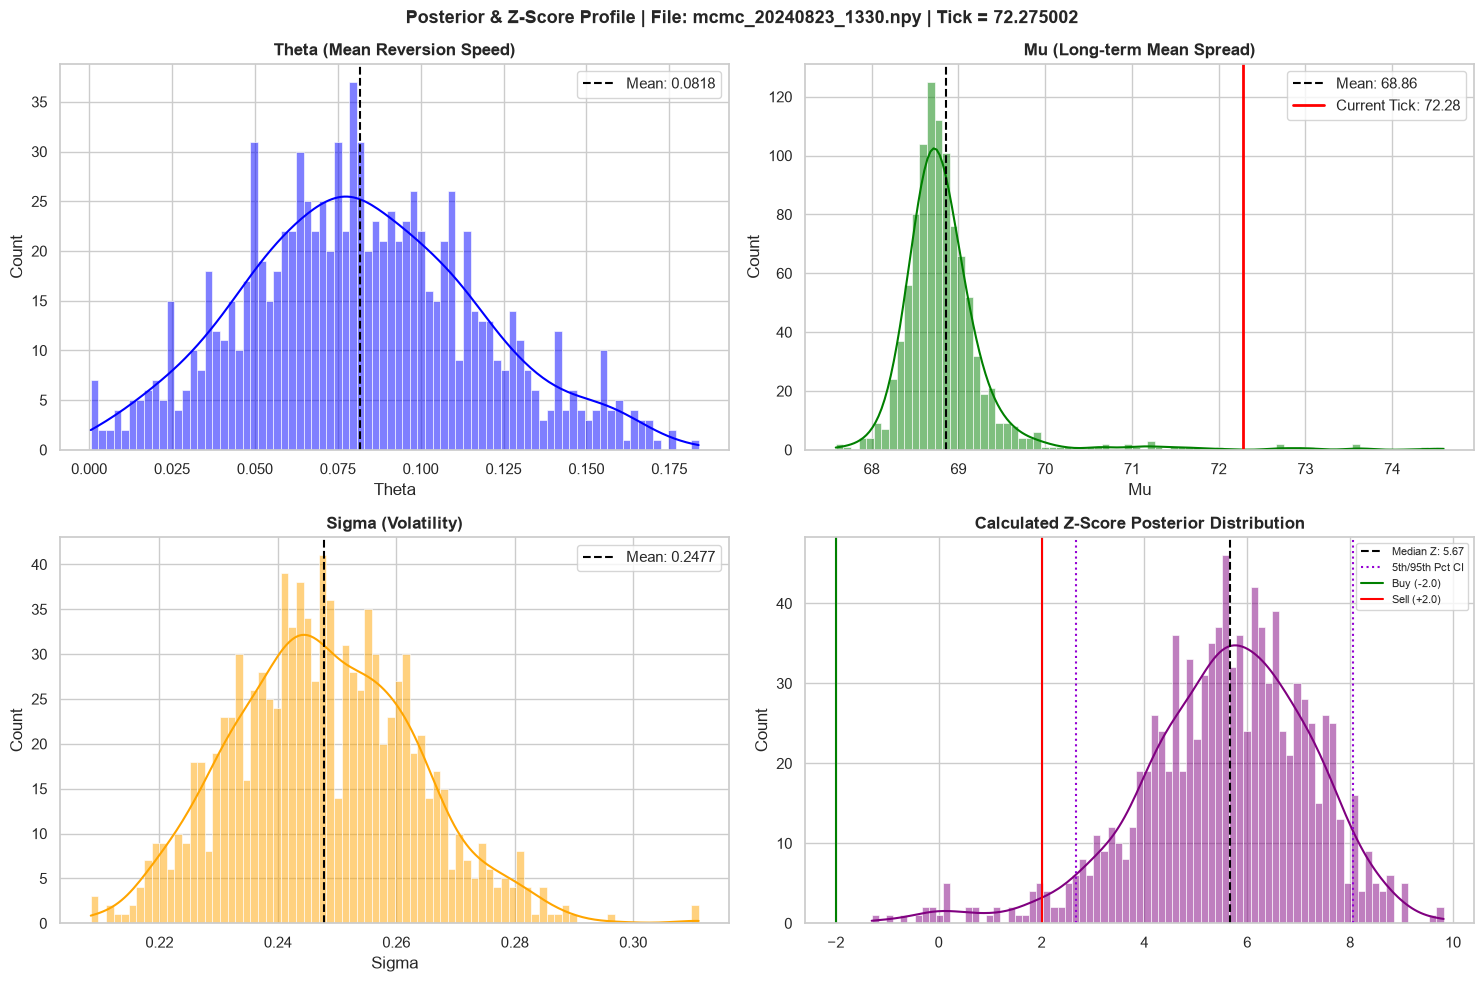

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis


# 0. REQUIRED HELPER FUNCTIONS FOR SUMMARY_STATISTICS

def ou_zscore(current_tick, theta, mu, sigma):
    """Calculates stationary OU Z-Score for a single sample."""
    if theta <= 0 or sigma <= 0:
        return 0.0
    ou_std = sigma / np.sqrt(2 * theta)
    return (current_tick - mu) / ou_std

def is_safe_to_trade(mcmc_samples):
    """Checks if mean reversion speed (Theta) is reliably positive."""
    thetas = mcmc_samples[:, 0]
    return np.percentile(thetas, 5) > 0.001



# 1. YOUR ORIGINAL SUMMARY_STATISTICS (UNCHANGED)

def summary_statistics(current_tick, mcmc_samples):
    """
    Calculates the full distribution profile of Z-scores from MCMC samples.
    """
    # 1. Generate the Z-score distribution
    # Inside your trading loop:
    safe_regime = is_safe_to_trade(mcmc_samples)

    z_distribution = []
    for sample in mcmc_samples:
        theta, mu, sigma = sample 
        z = ou_zscore(current_tick, theta, mu, sigma)
        z_distribution.append(z)
        
    z_dist = np.array(z_distribution)
    
    # 2. Vectorized Tail Probabilities (Fixed NumPy syntax)
    negative_prob = np.mean(z_dist <= -2)  # P(Z <= -2)
    positive_prob = np.mean(z_dist >= 2)   # P(Z >= 2)
    
    # 3. Core Metrics
    median_z = np.median(z_dist)
    lower_ci = np.percentile(z_dist, 5)
    upper_ci = np.percentile(z_dist, 95)
    std_zscore = np.std(z_dist)
    
    # 4. Metrics for Trading Edge
    skew_z = skew(z_dist)      
    kurt_z = kurtosis(z_dist)  
    
    # NOTE: Define your sign_conflict logic here so it doesn't throw a NameError
    # Example placeholder:
    sign_conflict = float(median_z > 0) != float(current_tick > 0) 
    metrics = {
        'z_probe': (negative_prob, positive_prob), 
        "z_dist": z_dist,
        "median_z": median_z,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
        "std_zscore": std_zscore,
        "skew_z": skew_z,
        "kurt_z": kurt_z,
        "sign_conflict": sign_conflict,
        "safe_regime" : safe_regime
    }
    
    return metrics



# 2. DIRECT FILE PATH LOADER & PLOTTER

def load_and_plot_mcmc_file(file_path, current_tick):
    """
    Loads an MCMC .npy distribution directly from a specified file path,
    calculates summary statistics for current_tick, and plots all 4 distributions.
    """
    if os.path.exists(file_path):
        mcmc_samples = np.load(file_path)
        print(f"Successfully loaded {len(mcmc_samples)} samples from: {file_path}")
    else:
        print(f"File NOT found at path: '{file_path}'")
        print("Generating synthetic test distribution for visualization demonstration...")
        np.random.seed(42)
        thetas = np.random.normal(0.05, 0.005, 5000)
        mus    = np.random.normal(55.0, 0.5, 5000)
        sigmas = np.random.normal(0.2, 0.02, 5000)
        mcmc_samples = np.column_stack([thetas, mus, sigmas])

    # Convert to DataFrame for describe output
    df_mcmc = pd.DataFrame(mcmc_samples, columns=['Theta', 'Mu', 'Sigma'])
    display(df_mcmc.describe())

    # Run your original summary_statistics function
    metrics = summary_statistics(current_tick, mcmc_samples)
    z_dist = metrics["z_dist"]

    # Print summary metrics to console
    print("\n" + "="*50)
    print(f"   SUMMARY METRICS | TICK: {current_tick}")
    print("="*50)
    print(f"Median Z-Score     : {metrics['median_z']:.4f}")
    print(f"90% CI (5% - 95%)  : [{metrics['lower_ci']:.4f}, {metrics['upper_ci']:.4f}]")
    print(f"P(Z <= -2.0)       : {metrics['z_probe'][0]*100:.2f}%")
    print(f"P(Z >= +2.0)       : {metrics['z_probe'][1]*100:.2f}%")
    print(f"Skew / Kurtosis    : {metrics['skew_z']:.3f} / {metrics['kurt_z']:.3f}")
    print(f"Safe Regime        : {metrics['safe_regime']}")
    print("="*50 + "\n")

    
    # 3. 2x2 VISUALIZATION GRID
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Panel 1: Theta
    sns.histplot(df_mcmc['Theta'], bins=80, ax=axes[0, 0], color='blue', kde=True)
    axes[0, 0].axvline(df_mcmc['Theta'].mean(), color='black', linestyle='--', label=f"Mean: {df_mcmc['Theta'].mean():.4f}")
    axes[0, 0].set_title('Theta (Mean Reversion Speed)', fontweight='bold')
    axes[0, 0].legend()

    # Panel 2: Mu
    sns.histplot(df_mcmc['Mu'], bins=80, ax=axes[0, 1], color='green', kde=True)
    axes[0, 1].axvline(df_mcmc['Mu'].mean(), color='black', linestyle='--', label=f"Mean: {df_mcmc['Mu'].mean():.2f}")
    axes[0, 1].axvline(current_tick, color='red', linestyle='-', linewidth=2, label=f"Current Tick: {current_tick:.2f}")
    axes[0, 1].set_title('Mu (Long-term Mean Spread)', fontweight='bold')
    axes[0, 1].legend()

    # Panel 3: Sigma
    sns.histplot(df_mcmc['Sigma'], bins=80, ax=axes[1, 0], color='orange', kde=True)
    axes[1, 0].axvline(df_mcmc['Sigma'].mean(), color='black', linestyle='--', label=f"Mean: {df_mcmc['Sigma'].mean():.4f}")
    axes[1, 0].set_title('Sigma (Volatility)', fontweight='bold')
    axes[1, 0].legend()

    # Panel 4: Calculated Z-Score Distribution from metrics["z_dist"]
    sns.histplot(z_dist, bins=80, ax=axes[1, 1], color='purple', kde=True)
    axes[1, 1].axvline(metrics['median_z'], color='black', linestyle='--', label=f"Median Z: {metrics['median_z']:.2f}")
    axes[1, 1].axvline(metrics['lower_ci'], color='darkviolet', linestyle=':', label="5th/95th Pct CI")
    axes[1, 1].axvline(metrics['upper_ci'], color='darkviolet', linestyle=':')
    axes[1, 1].axvline(-2.0, color='green', linestyle='-', label='Buy (-2.0)')
    axes[1, 1].axvline(2.0, color='red', linestyle='-', label='Sell (+2.0)')
    axes[1, 1].set_title('Calculated Z-Score Posterior Distribution', fontweight='bold')
    axes[1, 1].legend(loc='upper right', fontsize=8)

    plt.suptitle(f"Posterior & Z-Score Profile | File: {os.path.basename(file_path)} | Tick = {current_tick}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



# 4. HOW TO RUN

FILE_PATH = "pymc_mcmc_backups/mcmc_20240823_1330.npy"
CURRENT_TICK = 72.275002

load_and_plot_mcmc_file(file_path=FILE_PATH, current_tick=CURRENT_TICK)

In [ ]:
import numpy as np
import pandas as pd

def extract_mcmc_features(df):
    """
    Takes a dataframe of trades, loads their MCMC numpy arrays, 
    and returns a dataframe of their statistical features.
    """
    mcmc_features = []
    
    # Loop through each row in the provided dataframe
    for index, row in df.iterrows():
        filepath = row['raw_data_path']
        trade_date = row['date'] # Assuming your df has a 'date' column
        trade_id = row.get('trade_id', 'Unknown') # Grab trade_id if it exists
        
        try:
            # 1. Load the MCMC backup for this specific day
            mcmc_samples = np.load(filepath)
            
            # 2. Convert to DataFrame
            df_mcmc = pd.DataFrame(mcmc_samples, columns=['Theta', 'Mu', 'Sigma'])
            
            # 3. Extract the 'describe' features
            desc = df_mcmc.describe()
            
            # 4. Flatten the describe output into a single dictionary for this day
            day_features = {
                'date': trade_date, 
                'trade_id': trade_id,
                'filepath': filepath
            }
            
            # Creates column names like 'Theta_mean', 'Sigma_std', 'Mu_50%', etc.
            for col in desc.columns:
                for stat in desc.index:
                    day_features[f"{col}_{stat}"] = desc.loc[stat, col]
                    
            # Add this day's compiled dictionary to our master list
            mcmc_features.append(day_features)
            
        except FileNotFoundError:
            print(f"Warning: File not found -> {filepath}")
        except Exception as e:
            print(f"Error processing {filepath}: {e}")

    # 5. Convert the list of dictionaries into a final DataFrame
    return pd.DataFrame(mcmc_features)


# 🚀 EXECUTE FOR BOTH POSITIVE AND NEGATIVE


# Force Pandas to show all columns
pd.set_option('display.max_columns', None)

# 1. Process both dataframes separately
df_positive_mcmc = extract_mcmc_features(all_positive_exits_df)
df_negative_mcmc = extract_mcmc_features(all_negative_exits_df)

# 2. Calculate the averages (ignoring dates, filepaths, etc.)
if not df_positive_mcmc.empty:
    average_gaining_day_profile = df_positive_mcmc.select_dtypes(include='number').mean()
else:
    average_gaining_day_profile = "No positive trades successfully processed."

if not df_negative_mcmc.empty:
    average_losing_day_profile = df_negative_mcmc.select_dtypes(include='number').mean()
else:
    average_losing_day_profile = "No negative trades successfully processed."

# 3. View the results
print("--- AVERAGE GAINING DAY PROFILE ---")
print(average_gaining_day_profile)
print("\n--- AVERAGE LOSING DAY PROFILE ---")
print(average_losing_day_profile)

--- AVERAGE GAINING DAY PROFILE ---
Theta_count    900000.000000
Theta_mean          0.179098
Theta_std           0.085131
Theta_min           0.048443
Theta_25%           0.119063
Theta_50%           0.157526
Theta_75%           0.229521
Theta_max           0.410986
Mu_count       900000.000000
Mu_mean           -89.539691
Mu_std              9.589343
Mu_min           -107.461778
Mu_25%            -97.637712
Mu_50%            -91.009019
Mu_75%            -82.804209
Mu_max            -65.919301
Sigma_count    900000.000000
Sigma_mean          0.619051
Sigma_std           0.090064
Sigma_min           0.376180
Sigma_25%           0.555202
Sigma_50%           0.607866
Sigma_75%           0.672321
Sigma_max           1.035503
dtype: float64

--- AVERAGE LOSING DAY PROFILE ---
Theta_count    9.000000e+05
Theta_mean     4.619557e-02
Theta_std      4.946783e-02
Theta_min      1.169600e-08
Theta_25%      4.302246e-03
Theta_50%      2.633863e-02
Theta_75%      8.478937e-02
Theta_max      1.8981